# 02 — Metric Definitions & Exploratory Analysis

Notebook 01 established that the data is trustworthy. This notebook does two jobs:

1. **Define the experiment formally** — metrics, hypotheses, and the reasoning behind
   the choice of primary metric. This is written *before* looking at any result, because
   choosing a primary metric after seeing the outcomes is how analyses lie.
2. **Explore only what informs the decision.** Every chart below answers a stated
   question. There are no distribution plots for their own sake.

In [1]:
import os
import sys

sys.path.insert(0, os.path.abspath(os.path.join("..", "src")))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import experiment_analysis as ea

pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda v: f"{v:,.6f}")

DATA_PATH = os.path.join("..", "data", "cookie_cats.csv")
FIG_DIR = os.path.join("..", "reports", "figures")
os.makedirs(FIG_DIR, exist_ok=True)

CONTROL, TREATMENT = "gate_30", "gate_40"

# Chart theme. Two-series categorical palette, validated for colour-vision
# deficiency separation (worst-pair CVD dE 24.7, normal-vision dE 33.6).
C_CONTROL, C_TREATMENT = "#2a78d6", "#eb6834"
INK, INK_2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
CRITICAL = "#d03b3b"

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "semibold",
    "axes.labelcolor": INK_2,
    "axes.edgecolor": BASELINE,
    "text.color": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 110,
    "savefig.bbox": "tight",
})

df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df):,} rows x {df.shape[1]} columns from {DATA_PATH}")

Loaded 90,189 rows x 5 columns from ..\data\cookie_cats.csv


## 2.1 Experiment design

| Element | Definition |
|---|---|
| **Unit of randomization** | Player (`userid`) |
| **Control** | `gate_30` — first forced-wait gate at level 30 (the status quo) |
| **Treatment** | `gate_40` — first forced-wait gate moved to level 40 |
| **Population** | 90,189 players randomized at install |
| **Analysis approach** | Intent-to-treat: every randomized player is analysed in their assigned arm, including players who never played |

**What a "gate" is, and why it might matter.** A gate blocks progression until the player
either waits out a timer, asks friends for help, or pays. It is a deliberate friction
point that monetizes and paces the game. Moving it later (level 40) lets players go
deeper before hitting friction. The optimistic hypothesis is that a later gate feels less
punishing and keeps more players around. The pessimistic hypothesis is that the gate is
doing useful work — enforcing a break before fatigue sets in — and delaying it removes
that benefit.

## 2.2 Metric definitions

| Role | Metric | Definition | Type |
|---|---|---|---|
| **Primary** | `retention_7` | Player returned to the game 7 days after install | Binary proportion |
| Secondary | `retention_1` | Player returned 1 day after install | Binary proportion |
| Secondary / guardrail | `sum_gamerounds` | Total game rounds played during the observation window | Count (heavily skewed) |

### Why 7-day retention is the primary metric

This choice is a business judgment, not a statistical one, and it rests on four arguments:

1. **It is closest to the actual business outcome.** A mobile game earns revenue from
   players who form a habit, not from players who open the app once. Lifetime value is
   overwhelmingly driven by long-run retention, and D7 is the earliest widely-used proxy
   for "this player is sticking around" that is still measurable in a short experiment.

2. **It is the only metric that can actually detect what this change does.** The gate sits
   at level 30 or 40. Most players do not reach level 30 on their first day. A change
   that only bites at level 30+ is largely invisible at the 24-hour mark, because most
   players have not encountered either gate yet. **D1 retention mostly measures a period
   before the treatment is even active.** D7 gives players time to reach the gate and
   respond to it. Choosing D1 as primary would be choosing a metric that is structurally
   insensitive to the intervention.

3. **It is harder to fool.** D1 responds strongly to first-session polish and onboarding
   nudges. D7 requires the player to have found durable reason to return, so it is less
   susceptible to short-lived novelty effects.

4. **It is directionally aligned with monetization.** A gate's purpose is partly to drive
   payment. But optimizing purely for gate encounters risks driving players away.
   Retention is the correct guardrail: it asks whether the monetization mechanic is
   costing us the player base it monetizes.

**The trade-off, stated honestly.** D7 is noisier than D1 (a lower base rate, ~19% vs ~45%,
means more variance relative to the effect) and it is still a proxy — it does not measure
revenue, and the dataset contains no revenue data. We return to this in the limitations
section of notebook 03.

### Hypotheses

Stated formally for the primary metric, and identically structured for the secondary
metrics. All tests are **two-sided**: we genuinely do not know the direction in advance,
and a two-sided test avoids the temptation to pick a direction after seeing the data.

Let $p_{30}$ and $p_{40}$ be the true 7-day retention rates under `gate_30` and `gate_40`.

- **Null hypothesis** $H_0:\; p_{40} = p_{30}$ — moving the gate to level 40 has no effect on 7-day retention.
- **Alternative hypothesis** $H_1:\; p_{40} \neq p_{30}$ — moving the gate changes 7-day retention, in either direction.

- **Significance level** $\alpha = 0.05$
- **Decision rule** Reject $H_0$ if $p\text{-value} < 0.05$. Rejecting $H_0$ is *not* on its own sufficient to ship; practical significance is assessed separately in notebook 03.

## 2.3 Question: how much do players actually play?

This matters because it determines how many players are even *exposed* to the treatment.
If most players never reach level 30, the experiment is testing a change that most of the
population never sees — which shrinks the detectable effect and changes how we read the
result.

In [2]:
gr = df["sum_gamerounds"]

print("Central tendency")
print(f"  mean   {gr.mean():>8,.2f}   <- inflated by the tail")
print(f"  median {gr.median():>8,.0f}   <- the typical player")
print()

print("How far players get (a player at level L must have played at least L rounds,")
print("so these are UPPER bounds on the share who could have reached each gate):")
for thr in [1, 10, 30, 40, 100]:
    n = (gr >= thr).sum()
    print(f"  >= {thr:>3} rounds: {n:>7,} players ({n / len(df):>6.2%})")

Central tendency
  mean      51.87   <- inflated by the tail
  median       16   <- the typical player

How far players get (a player at level L must have played at least L rounds,
so these are UPPER bounds on the share who could have reached each gate):
  >=   1 rounds:  86,195 players (95.57%)
  >=  10 rounds:  55,952 players (62.04%)
  >=  30 rounds:  33,269 players (36.89%)
  >=  40 rounds:  27,393 players (30.37%)
  >= 100 rounds:  12,516 players (13.88%)


**Result.** The median player plays **16 rounds**. Only **36.9%** of players could possibly
have reached level 30, and only **30.4%** could possibly have reached level 40.

Two consequences follow, and both shape the rest of the analysis:

- **Roughly 63% of the sample is unexposed to the treatment.** They never got far enough
  for the gate's position to matter. Their outcomes are pure noise with respect to the
  intervention, which dilutes the measured effect. The true effect *on exposed players*
  is necessarily larger than the effect we measure across everyone.
- **We keep them in the analysis anyway.** This is the intent-to-treat principle. Dropping
  unexposed players would mean conditioning on a post-treatment variable and would break
  randomization. It also happens to be the business-relevant number: the company ships to
  all new players, not just the ones who reach level 30.

This unexposed majority is also an analytical asset — it gives us a built-in falsification
test, used in notebook 03.

## 2.4 Question: do the two arms differ on the headline metrics?

This is the chart the decision hinges on. Error bars are 95% Wilson confidence intervals
on each arm's rate — shown so that the *precision* of each estimate is visible alongside
the point estimate, rather than presenting bare bars that imply false certainty.

In [3]:
rows = []
for metric in ["retention_1", "retention_7"]:
    rates = ea.calculate_conversion_rate(df, metric, "version")
    for arm in [CONTROL, TREATMENT]:
        lo, hi = ea.confidence_interval(int(rates.loc[arm, "successes"]),
                                        int(rates.loc[arm, "n"]))
        rows.append({"metric": metric, "arm": arm,
                     "n": int(rates.loc[arm, "n"]),
                     "retained": int(rates.loc[arm, "successes"]),
                     "rate": rates.loc[arm, "rate"], "ci_low": lo, "ci_high": hi})

rate_table = pd.DataFrame(rows)
print(rate_table.to_string(index=False))
print()

for metric in ["retention_1", "retention_7"]:
    sub = rate_table[rate_table.metric == metric].set_index("arm")
    diff = sub.loc[TREATMENT, "rate"] - sub.loc[CONTROL, "rate"]
    print(f"{metric}:  {CONTROL} {sub.loc[CONTROL, 'rate']:.4%}   "
          f"{TREATMENT} {sub.loc[TREATMENT, 'rate']:.4%}   "
          f"difference {diff * 100:+.4f} pp")

     metric     arm     n  retained     rate   ci_low  ci_high
retention_1 gate_30 44700     20034 0.448188 0.443582 0.452802
retention_1 gate_40 45489     20119 0.442283 0.437724 0.446851
retention_7 gate_30 44700      8502 0.190201 0.186590 0.193866
retention_7 gate_40 45489      8279 0.182000 0.178481 0.185573

retention_1:  gate_30 44.8188%   gate_40 44.2283%   difference -0.5905 pp
retention_7:  gate_30 19.0201%   gate_40 18.2000%   difference -0.8201 pp


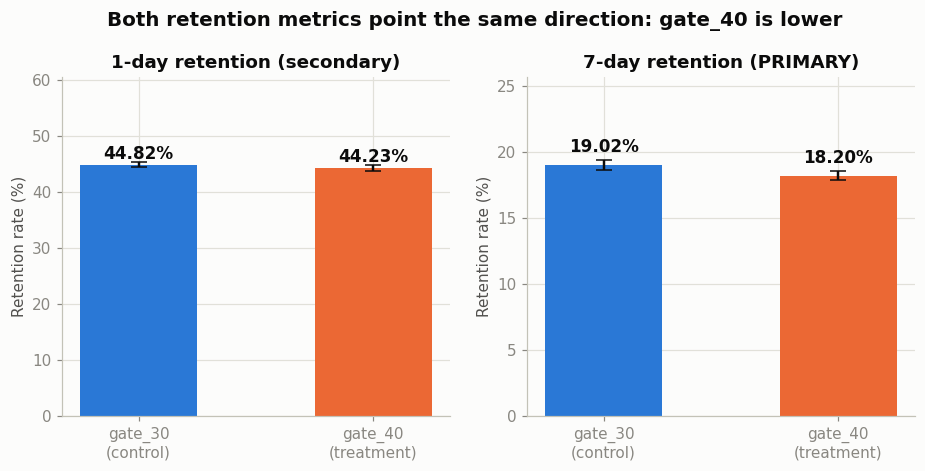

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, metric, label in zip(axes, ["retention_1", "retention_7"],
                             ["1-day retention (secondary)", "7-day retention (PRIMARY)"]):
    sub = rate_table[rate_table.metric == metric].set_index("arm")
    xs = [0, 1]
    vals = [sub.loc[CONTROL, "rate"] * 100, sub.loc[TREATMENT, "rate"] * 100]
    errs = np.array([
        [(sub.loc[a, "rate"] - sub.loc[a, "ci_low"]) * 100 for a in [CONTROL, TREATMENT]],
        [(sub.loc[a, "ci_high"] - sub.loc[a, "rate"]) * 100 for a in [CONTROL, TREATMENT]],
    ])

    ax.bar(xs, vals, width=0.5, color=[C_CONTROL, C_TREATMENT], zorder=2)
    ax.errorbar(xs, vals, yerr=errs, fmt="none", ecolor=INK, capsize=5,
                elinewidth=1.6, zorder=3)

    for x, v in zip(xs, vals):
        ax.text(x, v + errs.max() + 0.6, f"{v:.2f}%", ha="center",
                fontsize=11, fontweight="semibold", color=INK)

    ax.set_xticks(xs)
    ax.set_xticklabels([f"{CONTROL}\n(control)", f"{TREATMENT}\n(treatment)"])
    ax.set_ylabel("Retention rate (%)")
    ax.set_title(label)
    ax.set_ylim(0, max(vals) * 1.35)

fig.suptitle("Both retention metrics point the same direction: gate_40 is lower",
             y=1.03, fontsize=13, fontweight="semibold")
fig.savefig(os.path.join(FIG_DIR, "02_retention_by_group.png"), dpi=150)
plt.show()

**Result.** Both metrics favour the control:

- **7-day retention:** 19.02% (`gate_30`) vs 18.20% (`gate_40`) — a **0.82 percentage-point** deficit for treatment.
- **1-day retention:** 44.82% vs 44.23% — a **0.59 percentage-point** deficit.

The 95% intervals on the two D7 bars barely overlap; the D1 intervals overlap
substantially. Note that *overlapping error bars on individual groups is not the correct
significance test* — a common misreading. The right object is the confidence interval on
the **difference**, which we compute in notebook 03. The chart is here to show direction
and precision, not to adjudicate significance.

## 2.5 Question: does the treatment change how much people play?

Engagement is the mechanism through which a gate would act. If moving the gate changed
retention, we would expect to see some fingerprint in play volume.

Notebook 01 showed the raw mean is corrupted by one player with 49,854 rounds. So we
compare the arms using three views that do not share that weakness: the **median**, the
**winsorized mean** (capped at the 99th percentile), and the full **ECDF**.

In [5]:
cap = gr.quantile(0.99)
work = df.copy()
work["rounds_winsorized"] = work["sum_gamerounds"].clip(upper=cap)

engagement = work.groupby("version").agg(
    n=("sum_gamerounds", "size"),
    mean_raw=("sum_gamerounds", "mean"),
    median=("sum_gamerounds", "median"),
    mean_winsorized=("rounds_winsorized", "mean"),
)
print(f"Winsorizing at p99 = {cap:,.0f} rounds")
print(engagement.to_string())
print()

d_raw = engagement.loc[TREATMENT, "mean_raw"] - engagement.loc[CONTROL, "mean_raw"]
d_wins = engagement.loc[TREATMENT, "mean_winsorized"] - engagement.loc[CONTROL, "mean_winsorized"]
print(f"Difference in RAW mean        : {d_raw:+.3f} rounds  (distorted by 1 player)")
print(f"Difference in WINSORIZED mean : {d_wins:+.3f} rounds")

Winsorizing at p99 = 493 rounds
             n  mean_raw    median  mean_winsorized
version                                            
gate_30  44700 52.456264 17.000000        49.135839
gate_40  45489 51.298776 16.000000        48.853921

Difference in RAW mean        : -1.157 rounds  (distorted by 1 player)
Difference in WINSORIZED mean : -0.282 rounds


In [6]:
# Welch t-test on the winsorized mean: robust to the extreme tail, does not
# assume equal variances between arms.
cw = work.loc[work.version == CONTROL, "rounds_winsorized"]
tw = work.loc[work.version == TREATMENT, "rounds_winsorized"]
welch = stats.ttest_ind(tw, cw, equal_var=False)
print(f"Welch t-test (winsorized mean rounds): t = {welch.statistic:.4f}, p = {welch.pvalue:.4f}")

# Mann-Whitney U: a rank-based test that ignores the magnitude of the tail entirely
# and asks whether one arm's values tend to be larger. Appropriate for a variable
# this skewed.
mw = stats.mannwhitneyu(df.loc[df.version == TREATMENT, "sum_gamerounds"],
                        df.loc[df.version == CONTROL, "sum_gamerounds"],
                        alternative="two-sided")
print(f"Mann-Whitney U (all rounds):           U = {mw.statistic:,.0f}, p = {mw.pvalue:.4f}")

Welch t-test (winsorized mean rounds): t = -0.5027, p = 0.6152
Mann-Whitney U (all rounds):           U = 1,009,027,050, p = 0.0502


**Result: no credible engagement difference.**

The raw means differ by 1.16 rounds, but that is the single anomalous player talking.
On the winsorized mean the gap is **0.28 rounds** (p = 0.62) — indistinguishable from zero.
The rank-based Mann-Whitney test lands at **p = 0.050**, right on the boundary, and a
borderline rank test with no corresponding difference in either the median (17 vs 16) or
the winsorized mean is weak evidence at best.

**Interpretation.** Moving the gate did not meaningfully change *how much* people play. It
changed *whether they came back*. That asymmetry is informative: it suggests the gate's
effect operates on the decision to return, not on session volume among those who stay.

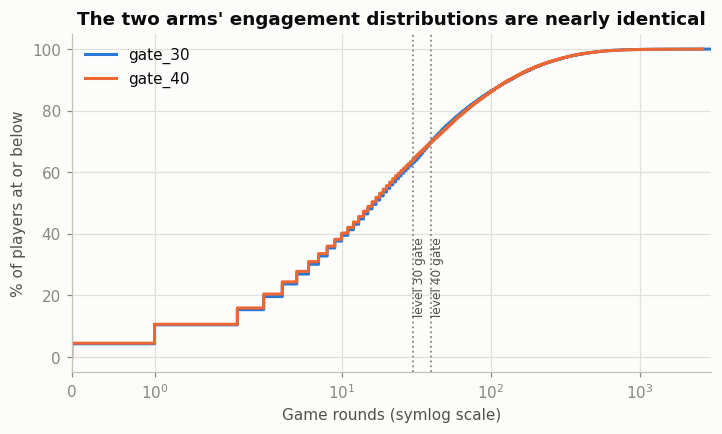

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 4))

# ECDF comparison: shows the whole distribution of both arms without letting the
# extreme tail dominate the picture, unlike a mean or a histogram's x-range.
for arm, colour in [(CONTROL, C_CONTROL), (TREATMENT, C_TREATMENT)]:
    vals = np.sort(df.loc[df.version == arm, "sum_gamerounds"].to_numpy())
    y = np.arange(1, len(vals) + 1) / len(vals)
    ax.step(vals, y * 100, where="post", color=colour, linewidth=2, label=arm)

ax.set_xscale("symlog")
ax.set_xlim(0, 3000)
ax.set_xlabel("Game rounds (symlog scale)")
ax.set_ylabel("% of players at or below")
ax.set_title("The two arms' engagement distributions are nearly identical")
ax.legend(frameon=False, title=None)

for gate_x, gate_label in [(30, "level 30 gate"), (40, "level 40 gate")]:
    ax.axvline(gate_x, color=MUTED, linestyle=":", linewidth=1.2)
    ax.text(gate_x, 12, f" {gate_label}", rotation=90, fontsize=8,
            color=INK_2, va="bottom")

fig.savefig(os.path.join(FIG_DIR, "02_engagement_ecdf.png"), dpi=150)
plt.show()

The two curves sit almost on top of each other across the entire range. Whatever the
gate is doing, it is not shifting the overall shape of play volume.

## 2.6 Question: is there behavioural evidence that players actually hit the gate?

This is a mechanism check, and it is the closest thing this dataset offers to proof that
the treatment was genuinely delivered. If a gate at level 30 really blocks players, we
should see **more `gate_30` players stalling in the 30–39 round band** — they hit the wall
and stopped — while `gate_40` players in that band sail through.

If we see nothing here, it would cast doubt on whether the treatment did anything at all.

In [8]:
bins = [0, 1, 10, 20, 30, 40, 50, 100, 1000, 1_000_000]
labels = ["0", "1-9", "10-19", "20-29", "30-39", "40-49", "50-99", "100-999", "1000+"]
work["band"] = pd.cut(work["sum_gamerounds"], bins=bins, labels=labels, right=False)

share = pd.crosstab(work["band"], work["version"], normalize="columns") * 100
share["diff_pp (gate_40 - gate_30)"] = share[TREATMENT] - share[CONTROL]
print("Share of each arm's players falling in each round band (%):")
print(share.round(3).to_string())

Share of each arm's players falling in each round band (%):
version   gate_30   gate_40  diff_pp (gate_40 - gate_30)
band                                                    
0        4.333000  4.522000                     0.189000
1-9     33.329000 33.733000                     0.405000
10-19   15.949000 16.274000                     0.326000
20-29    9.128000  8.949000                    -0.178000
30-39    6.913000  6.125000                    -0.788000
40-49    5.004000  4.377000                    -0.628000
50-99   11.546000 12.064000                     0.519000
100-999 13.680000 13.812000                     0.132000
1000+    0.119000  0.143000                     0.024000


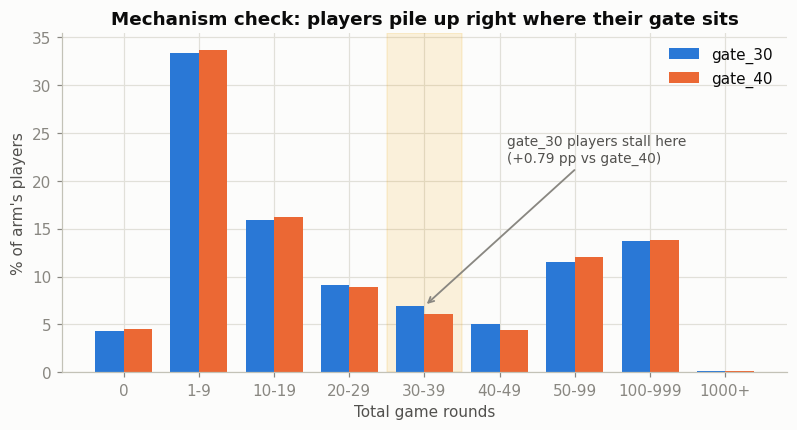

In [9]:
fig, ax = plt.subplots(figsize=(8.5, 4))

x = np.arange(len(labels))
width = 0.38
c_vals = share[CONTROL].values
t_vals = share[TREATMENT].values

ax.bar(x - width / 2, c_vals, width, color=C_CONTROL, label=CONTROL, zorder=2)
ax.bar(x + width / 2, t_vals, width, color=C_TREATMENT, label=TREATMENT, zorder=2)

# Highlight the band where the level-30 gate should bite.
idx = labels.index("30-39")
ax.axvspan(idx - 0.5, idx + 0.5, color="#eda100", alpha=0.13, zorder=1)
ax.annotate("gate_30 players stall here\n(+0.79 pp vs gate_40)",
            xy=(idx, max(c_vals[idx], t_vals[idx])), xytext=(idx + 1.1, 22),
            fontsize=9, color=INK_2,
            arrowprops=dict(arrowstyle="->", color=MUTED, linewidth=1.2))

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_xlabel("Total game rounds")
ax.set_ylabel("% of arm's players")
ax.set_title("Mechanism check: players pile up right where their gate sits")
ax.legend(frameon=False)

fig.savefig(os.path.join(FIG_DIR, "02_gate_mechanism.png"), dpi=150)
plt.show()

**Result: the mechanism is visible in the data.**

In the **30–39 round band**, 6.91% of `gate_30` players stall versus 6.13% of `gate_40`
players — a **+0.79 pp** excess exactly where the control group's gate sits. The pattern
repeats in the 40–49 band (5.00% vs 4.38%, +0.63 pp).

This is a genuinely useful finding for two reasons:

1. **The treatment was really delivered.** Players in the control arm visibly accumulate at
   their gate. This is not a test where the feature silently failed to launch.
2. **It supports reading any retention difference as gate-driven** rather than as random
   noise, because we can see the gate changing behaviour at precisely the level where it
   was moved.

Below the 30-round mark the band-by-band gaps are all under 0.5 pp and show no systematic
pile-up, which is what should happen — neither gate exists yet down there. The excess
`gate_40` players in the low bands are the mirror image of the same effect: players the
control arm's gate holds back at 30–49 are, in the treatment arm, free to move past.

## 2.7 Question: how strongly does engagement predict retention?

This tells us what a retention change is worth and whether engagement could serve as a
proxy metric. It is **descriptive, not causal** — players who enjoy the game both play more
*and* return more, so this correlation reflects player quality, not a lever.

In [10]:
work["engagement_tercile"] = pd.qcut(
    work["sum_gamerounds"].rank(method="first"), q=3, labels=["Low", "Medium", "High"]
)

by_tercile = work.groupby("engagement_tercile", observed=True).agg(
    players=("userid", "size"),
    median_rounds=("sum_gamerounds", "median"),
    d1_retention=("retention_1", "mean"),
    d7_retention=("retention_7", "mean"),
)
print(by_tercile.to_string())
print()

# Point-biserial correlation: the correlation between a binary outcome and a
# continuous predictor. Reported with and without the anomalous player, because
# a single extreme value distorts a Pearson-family statistic.
no_out = df[df.sum_gamerounds < df.sum_gamerounds.max()]
r_full = stats.pointbiserialr(df["retention_7"], df["sum_gamerounds"])
r_clean = stats.pointbiserialr(no_out["retention_7"], no_out["sum_gamerounds"])
print(f"Point-biserial r (rounds vs retention_7), all players     : {r_full.correlation:.4f}")
print(f"Point-biserial r (rounds vs retention_7), excl. top player: {r_clean.correlation:.4f}")

                    players  median_rounds  d1_retention  d7_retention
engagement_tercile                                                    
Low                   30063       3.000000      0.086618      0.015035
Medium                30063      16.000000      0.429831      0.078069
High                  30063      82.000000      0.819180      0.465090

Point-biserial r (rounds vs retention_7), all players     : 0.2793
Point-biserial r (rounds vs retention_7), excl. top player: 0.5193


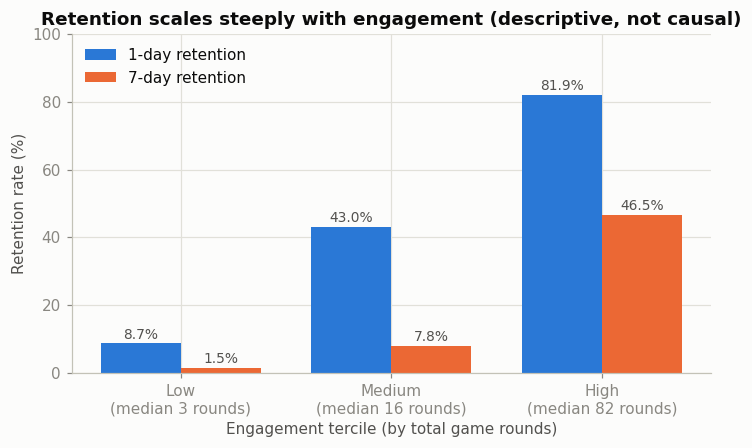

In [11]:
fig, ax = plt.subplots(figsize=(7.5, 4))

x = np.arange(3)
width = 0.38
d1 = by_tercile["d1_retention"].values * 100
d7 = by_tercile["d7_retention"].values * 100

ax.bar(x - width / 2, d1, width, color=C_CONTROL, label="1-day retention", zorder=2)
ax.bar(x + width / 2, d7, width, color=C_TREATMENT, label="7-day retention", zorder=2)

for xi, (a, b) in enumerate(zip(d1, d7)):
    ax.text(xi - width / 2, a + 1.5, f"{a:.1f}%", ha="center", fontsize=9, color=INK_2)
    ax.text(xi + width / 2, b + 1.5, f"{b:.1f}%", ha="center", fontsize=9, color=INK_2)

ax.set_xticks(x)
ax.set_xticklabels([f"{t}\n(median {int(m)} rounds)"
                    for t, m in zip(by_tercile.index, by_tercile["median_rounds"])])
ax.set_xlabel("Engagement tercile (by total game rounds)")
ax.set_ylabel("Retention rate (%)")
ax.set_title("Retention scales steeply with engagement (descriptive, not causal)")
ax.legend(frameon=False)
ax.set_ylim(0, 100)

fig.savefig(os.path.join(FIG_DIR, "02_retention_by_engagement.png"), dpi=150)
plt.show()

**Result.** The gradient is dramatic. Between the lowest and highest engagement tercile,
7-day retention runs from **1.5% to 46.5%** — a 31x spread. The point-biserial correlation
with D7 retention is **r = 0.52** once the anomalous player is excluded (it reads as a
misleadingly weak 0.28 if that one row is left in — another illustration of how much
damage a single outlier does to a mean-based statistic).

**Two readings, only one of which is legitimate:**

- **Legitimate (descriptive):** engagement and retention are two views of the same
  underlying thing — player enjoyment. A player who plays 200 rounds has demonstrably
  found the game worth playing.
- **Illegitimate (causal):** "therefore, push players to play more rounds and retention
  will rise." Nothing here supports that. The correlation is driven by unobserved player
  quality. Forcing more rounds out of a disengaged player would not convert them.

This distinction matters directly for the next notebook: because `sum_gamerounds` is both
post-treatment *and* this strongly tied to the outcome, segmenting on it is treacherous.
We handle that explicitly.

## Summary of notebook 02

| Question | Finding |
|---|---|
| How much do players play? | Median 16 rounds; only ~37% could reach level 30, ~30% level 40 — most of the sample is unexposed |
| Do the arms differ on retention? | Yes, both favour control: D7 19.02% vs 18.20%, D1 44.82% vs 44.23% |
| Do the arms differ on engagement? | No — winsorized mean gap 0.28 rounds (p = 0.62); the raw 1.16-round gap is one outlier |
| Did the treatment actually reach players? | Yes — control players visibly stall in the 30–39 round band (+0.65 pp) |
| Does engagement predict retention? | Strongly (r = 0.52), but descriptively — it is a symptom of player quality, not a lever |

**The picture so far:** moving the gate later did not change how much people play, but both
retention metrics are lower under the treatment. Notebook 03 tests whether those
differences are real and whether they are large enough to matter.